Imports

In [2]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from upsetplot import UpSet, from_indicators
import scipy.stats as stats


Constants and Global variables

In [3]:
GTF = "C:\\Users\\Ana\\Documents\\Estágio\\rmsk_TEIndividual.gtf"

# Expression constants
RODRIGUES_EXPRESSION_NPC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Expression_TE_DESeq_NPC.csv"
RODRIGUES_EXPRESSION_NEU = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NEU\\Expression_TE_DESeq_NEU.csv"
ALDINGER_EXPRESSION_TEMPORAL_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Expression_TE_DESeq_Cingluate_cortex.csv"
ALDINGER_EXPRESSION_CINGLUATE_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Expression_TE_DESeq_Temporal_cortex.csv"
GOGLIOTI_EXPRESSION_CEREBELLUM = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Expression_TE_DESeq_Cerebellum.csv"
GOGLIOTI_EXPRESSION_MOTOR_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Expression_TE_DESeq_Motor_cortex.csv"
SUN_EXPRESSION = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Expression_TE_DESeq.csv"
XIANG_EXPRESSION = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Expression_TE_DESeq.csv"
TANAKA_EXPRESSION = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Expression_TE_DESeq.csv"

# DEA constants
SUN_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\DEA_TE_DESeq.csv"
XIANG_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\DEA_TE_DESeq.csv"
TANAKA_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\DEA_TE_DESeq.csv"
GOGLIOTI_DEA_CEREBELLUM = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\DEA_TE_DESeq_Cerebellum.csv"
GOGLIOTI_DEA_MOTOR_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\DEA_TE_DESeq_Motor_cortex.csv"
RODRIGUES_DEA_NEU = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\DEA_TE_DESeq_Neu.csv"
RODRIGUES_DEA_NPC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\DEA_TE_DESeq_NPC.csv"
ALDINGER_DEA_CINGLUATE_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\DEA_TE_DESeq_Cingluate_cortex.csv"
ALDINGER_DEA_TEMPORAL_CORTEX = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\DEA_TE_DESeq_Temporal_cortex.csv"
LIU_DEA_KO = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\DEA_TE_DESeq_KO.csv"
LIU_DEA_R133C = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\DEA_TE_DESeq_R133C.csv"
LIU_DEA_R168X = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\DEA_TE_DESeq_R168X.csv"

# DETEs_DETEs
LIU_KO_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_DETEs_DETEs"
LIU_R133C_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_DETEs_DETEs"
LIU_R168X_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_DETEs_DETEs"
SUN_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Distances_DETEs_DETEs"
XIANG_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Distances_DETEs_DETEs"
TANAKA_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Distances_DETEs_DETEs"
GOGLIOTI_CEREBELLUM_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Distances_DETEs_DETEs"
GOGLIOTI_MOTOR_CORTEX_DETES_DETES ="C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Distances_DETEs_DETEs"
RODRIGUES_NPC_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_DETEs_DETEs"
RODRIGUES_NEU_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_DETEs_DETEs"
ALDINGER_CINGLUATE_CORTEX_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Distances_DETEs_DETEs"
ALDINGER_TEMPORAL_CORTEX_DETES_DETES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Distances_DETEs_DETEs"

# DETEs_TEs
LIU_KO_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_DETEs_TEs"
LIU_R133C_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_DETEs_TEs"
LIU_R168X_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_DETEs_TEs"
SUN_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Distances_DETEs_TEs"
XIANG_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Distances_DETEs_TEs"
TANAKA_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Distances_DETEs_TEs"
GOGLIOTI_CEREBELLUM_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Distances_DETEs_TEs"
GOGLIOTI_MOTOR_CORTEX_DETES_TES ="C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Distances_DETEs_TEs"
RODRIGUES_NPC_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_DETEs_TEs"
RODRIGUES_NEU_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_DETEs_TEs"
ALDINGER_CINGLUATE_CORTEX_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Distances_DETEs_TEs"
ALDINGER_TEMPORAL_CORTEX_DETES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Distances_DETEs_TEs"

# TEs_TEs
LIU_KO_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_TEs_TEs"
LIU_R133C_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_TEs_TEs"
LIU_R168X_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_TEs_TEs"
SUN_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Distances_TEs_TEs"
XIANG_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Distances_TEs_TEs"
TANAKA_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Distances_TEs_TEs"
GOGLIOTI_CEREBELLUM_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Distances_TEs_TEs"
GOGLIOTI_MOTOR_CORTEX_TES_TES ="C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Distances_TEs_TEs"
RODRIGUES_NPC_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_TEs_TEs"
RODRIGUES_NEU_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_TEs_TEs"
ALDINGER_CINGLUATE_CORTEX_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Distances_TEs_TEs"
ALDINGER_TEMPORAL_CORTEX_TES_TES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Distances_TEs_TEs"

# Up_Up
ALDINGER_CINGLUATE_CORTEX_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Aldinger2020_Cingluate_cortex_Up_Up.bed"
ALDINGER_TEMPORAL_CORTEX_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Aldinger2020_Temporal_cortex_Up_Up.bed"
GOGLIOTI_CEREBELLUM_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Goglioti2018_Cerebellum_Up_Up.bed"
GOGLIOTI_MOTOR_CORTEX_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Goglioti2018_Motor_cortex_Up_Up.bed"
RODRIGUES_NEU_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Rodrigues_Neu_Up_Up.bed"
RODRIGUES_NPC_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Rodrigues_NPC_Up_Up.bed"
LIU_KO_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_KO_Up_Up.bed"
LIU_R133C_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_R133C_Up_Up.bed"
LIU_R168X_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_R168X_Up_Up.bed"
SUN_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Sun_Up_Up.bed"
XIANG_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Xiang_Up_Up.bed"
TANAKA_UP_UP = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Tanaka_Up_Up.bed"

# Up_NS
ALDINGER_CINGLUATE_CORTEX_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Aldinger2020_Cingluate_cortex_Up_Ns.bed"
ALDINGER_TEMPORAL_CORTEX_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Aldinger2020_Temporal_cortex_Up_Ns.bed"
GOGLIOTI_CEREBELLUM_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Goglioti2018_Cerebellum_Up_Ns.bed"
GOGLIOTI_MOTOR_CORTEX_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Goglioti2018_Motor_cortex_Up_Ns.bed"
RODRIGUES_NEU_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Rodrigues_Neu_Up_Ns.bed"
RODRIGUES_NPC_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Rodrigues_NPC_Up_Ns.bed"
LIU_KO_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_KO_Up_Ns.bed"
LIU_R133C_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_R133C_Up_Ns.bed"
LIU_R168X_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Liu_R168X_Up_Ns.bed"
SUN_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Sun_Up_Ns.bed"
XIANG_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Xiang_Up_Ns.bed"
TANAKA_UP_NS = "C:\\Users\\Ana\\Documents\\Estágio\\BEDs\\02_Distance_BEDs_results\\Tanaka_Up_Ns.bed"

# Up_Up intergenic
RODRIGUES_NEU_UP_UP_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_Up_Up"
RODRIGUES_NPC_UP_UP_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_Up_Up"
LIU_KO_UP_UP_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_Up_Up"
LIU_R133C_UP_UP_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_Up_Up"
LIU_R168X_UP_UP_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_Up_Up"

# Up_Ns intergenic
RODRIGUES_NEU_UP_NS_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_Up_Ns"
RODRIGUES_NPC_UP_NS_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_Up_Ns"
LIU_KO_UP_NS_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_Up_Ns"
LIU_R133C_UP_NS_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_Up_Ns"
LIU_R168X_UP_NS_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_Up_Ns"

# Down_Down intergenic
RODRIGUES_NEU_DOWN_DOWN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_Down_Down"
RODRIGUES_NPC_DOWN_DOWN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_Down_Down"
LIU_KO_DOWN_DOWN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_Down_Down"
LIU_R133C_DOWN_DOWN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_Down_Down"
LIU_R168X_DOWN_DOWN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_Down_Down"

# DETE_DEG
ALDINGER_CINGLUATE_CORTEX_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Distances_DETEs_DEGs"
ALDINGER_TEMPORAL_CORTEX_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Distances_DETEs_DEGs"
GOGLIOTI_CEREBELLUM_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Distances_DETEs_DEGs"
GOGLIOTI_MOTOR_CORTEX_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Distances_DETEs_DEGs"
RODRIGUES_NEU_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_DETEs_DEGs"
RODRIGUES_NPC_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_DETEs_DEGs"
LIU_KO_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_DETEs_DEGs"
LIU_R133C_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_DETEs_DEGs"
LIU_R168X_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_DETEs_DEGs"
SUN_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Distances_DETEs_DEGs"
XIANG_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Distances_DETEs_DEGs"
TANAKA_DETEs_DEGs = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Distances_DETEs_DEGs"

# DETE_NS_GENE
ALDINGER_CINGLUATE_CORTEX_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\Distances_DETEs_NS_Genes"
ALDINGER_TEMPORAL_CORTEX_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Distances_DETEs_NS_Genes"
GOGLIOTI_CEREBELLUM_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Distances_DETEs_NS_Genes"
GOGLIOTI_MOTOR_CORTEX_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Distances_DETEs_NS_Genes"
RODRIGUES_NEU_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Distances_DETEs_Ns_Genes"
RODRIGUES_NPC_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\Distances_DETEs_NS_Genes"
LIU_KO_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\Distances_DETEs_NS_Genes"
LIU_R133C_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Distances_DETEs_NS_Genes"
LIU_R168X_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\Distances_DETEs_NS_Genes"
SUN_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Distances_DETEs_NS_Genes"
XIANG_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Distances_DETEs_NS_Genes"
TANAKA_DETEs_NS_GENES = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Distances_DETEs_NS_Genes"







DETEs

In [4]:
# Organizes the classification, according to the defined values
def organize_classification(dea_df):
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < 0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )
    
    dea_df = dea_df[dea_df['Classification'] != 'Non-significant']

    return dea_df

# Read the deas
def read_deas(dea_strings):
    dfs = []
    names = []
    count = 0

    for string in dea_strings:
        # Read deas
        df = pd.read_csv(string)
        df = df.dropna()
        df = organize_classification(df)

        dfs.append(df)
        count += df.shape[0]

        # Get the data set name
        parts = string.split("\\")
        if ((parts[-3] == "Aldinger2020") | (parts[-3] == 'Goglioti2018') | (parts[-3] == 'Rodrigues2020') | (parts[-3] == 'Liu2024')):
            name = parts[-3] + '\\' + parts[-2]
        else:
            name = parts[-2]
        names.append(name)
        
    print(f"Número de TEs: {count}")
    return dfs, names

# Read gtf as a data frame
def read_gtf(gtf, deas_strings, expression_files):
    gtf_df = pd.read_csv(gtf, sep = '\t', header = None, comment = '#')
    deas, names = read_deas(deas_strings)

    gtf_df.columns = ['Chr', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand', 'Frame', 'Attribute']

    remaining_columns = ['gene_id', 'gene_name', 'family_id', 'class_id']

    for column in remaining_columns:
        gtf_df[column.capitalize()] = gtf_df['Attribute'].apply(lambda attribute: re.findall(rf'{column} "([^"]*)"', attribute)[0] if rf'{column} "' in attribute else '')
        

    gtf_df.drop('Attribute', axis = 1, inplace = True)

    gtf_df = gtf_df[['Chr', 'Start', 'End', 'Gene_name', 'Score', 'Strand', 'Family_id', 'Class_id']]

    for i in range(len(deas)):
        print(names[i])
        deas[i] = deas[i].rename(columns = {'Unnamed: 0' : 'Gene_name'})
        print(deas[i])
        deas[i] = deas[i]['Gene_name']

        merged_df = gtf_df.merge(deas[i], on = 'Gene_name', how = 'inner')

        merged_df = merged_df.sort_values(['Chr', 'Start'])
        merged_df['Start'] = merged_df['Start'] - 1

        merged_df.to_csv(f"C:\\Users\\Ana\\Documents\\Estágio\\{names[i]}\\TE_DETEs", sep = '\t', header = False, index = False) # bed não tem cabeçalho, o índice da DataFrame não pode ir para o ficheiro
        print(merged_df.head())

    return gtf_df

deas_strings = [LIU_DEA_KO, LIU_DEA_R133C, LIU_DEA_R168X]

expression_files = [SUN_EXPRESSION, XIANG_EXPRESSION, TANAKA_EXPRESSION, ALDINGER_EXPRESSION_CINGLUATE_CORTEX,
                    ALDINGER_EXPRESSION_TEMPORAL_CORTEX, RODRIGUES_EXPRESSION_NEU, RODRIGUES_EXPRESSION_NPC,
                    GOGLIOTI_EXPRESSION_CEREBELLUM, GOGLIOTI_EXPRESSION_MOTOR_CORTEX]

gtf_df = read_gtf(GTF, deas_strings, expression_files)


Número de TEs: 43574
Liu2024\Liu2024_KO
                 Gene_name    baseMean  log2FoldChange     lfcSE       stat  \
0       TE_MER58A_dup10177  296.136900        5.300295  0.434757  12.191396   
1          TE_L2a_dup73868  245.715392        4.725447  0.419721  11.258533   
2     TE_HERVH-int_dup1414  348.370041        5.398390  0.497512  10.850770   
3          TE_MIR3_dup5877  170.578610        5.207047  0.494716  10.525332   
4     TE_HERVH-int_dup1411  149.311879        5.701412  0.553048  10.309070   
...                    ...         ...             ...       ...        ...   
8981      TE_LTR48B_dup468    4.936524        6.056888  1.981466   3.056771   
8982     TE_L1PA17_dup4394    8.550800        5.102516  1.669273   3.056730   
8983       TE_L1MA3_dup152    5.731422        5.565507  1.820911   3.056441   
8984      TE_MLT1H_dup8238    5.575038        5.420328  1.773383   3.056490   
8985      TE_MER89_dup1235    5.180401        5.912218  1.934354   3.056430   

           

For the non-significant

In [5]:
# Organizes the classification, according to the defined values
def organize_classification(dea_df):
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < 0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )
    
    dea_df = dea_df[dea_df['Classification'] == 'Non-significant']

    return dea_df

# Read the deas
def read_deas(dea_strings):
    dfs = []
    names = []
    count = 0

    for string in dea_strings:
        # Read deas
        df = pd.read_csv(string)
        df = df.dropna()
        df = organize_classification(df)

        dfs.append(df)
        count += df.shape[0]

        # Apply log2foldChange threshold if liu
        if ((string == LIU_DEA_KO) | (string == LIU_DEA_R133C) | (string == LIU_DEA_R168X)):
            df = df[df['log2FoldChange'] > abs(1)] # O que fica dentro do log é a expressão da condição A a dividir pela expressão da condição B


        # Get the data set name
        parts = string.split("\\")
        if ((parts[-3] == "Aldinger2020") | (parts[-3] == 'Goglioti2018') | (parts[-3] == 'Rodrigues2020') | (parts[-3] == 'Liu2024')):
            name = parts[-3] + '\\' + parts[-2]
        else:
            name = parts[-2]
        names.append(name)
        
    print(f"Número de TEs: {count}")
    return dfs, names

# Read gtf as a data frame
def read_gtf(gtf, deas_strings, expression_files):
    gtf_df = pd.read_csv(gtf, sep = '\t', header = None, comment = '#')
    deas, names = read_deas(deas_strings)

    gtf_df.columns = ['Chr', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand', 'Frame', 'Attribute']

    remaining_columns = ['gene_id', 'gene_name', 'family_id', 'class_id']

    for column in remaining_columns:
        gtf_df[column.capitalize()] = gtf_df['Attribute'].apply(lambda attribute: re.findall(rf'{column} "([^"]*)"', attribute)[0] if rf'{column} "' in attribute else '')
        

    gtf_df.drop('Attribute', axis = 1, inplace = True)

    gtf_df = gtf_df[['Chr', 'Start', 'End', 'Gene_name', 'Score', 'Strand', 'Family_id', 'Class_id']]

    for i in range(len(deas)):
        print(names[i])
        deas[i] = deas[i].rename(columns = {'Unnamed: 0' : 'Gene_name'})
        print(deas[i])
        deas[i] = deas[i]['Gene_name']

        merged_df = gtf_df.merge(deas[i], on = 'Gene_name', how = 'inner')

        merged_df = merged_df.sort_values(['Chr', 'Start'])
        merged_df['Start'] = merged_df['Start'] - 1

        merged_df.to_csv(f"C:\\Users\\Ana\\Documents\\Estágio\\{names[i]}\\TE_Non_significant", sep = '\t', header = False, index = False) # bed não tem cabeçalho, o índice da DataFrame não pode ir para o ficheiro
        print(merged_df.head())

deas_strings = [LIU_DEA_KO, LIU_DEA_R133C, LIU_DEA_R168X]

read_gtf(GTF, deas_strings, expression_files)

Número de TEs: 651633
Liu2024\Liu2024_KO
                    Gene_name   baseMean  log2FoldChange     lfcSE      stat  \
8986         TE_L2c_dup117250   9.624720        5.235547  1.713020  3.056325   
8987         TE_AluY_dup77121   7.705235        5.175226  1.693308  3.056282   
8988          TE_L2a_dup11863   6.274348        5.684229  1.859961  3.056101   
8989         TE_L1MB7_dup3315  12.518155        3.243326  1.061336  3.055890   
8990         TE_L1MA4_dup5965   9.215491        4.486201  1.468053  3.055884   
...                       ...        ...             ...       ...       ...   
200543        TE_FRAM_dup7487   5.442752       -0.000310  1.333247 -0.000232   
200544  TE_ERVL-E-int_dup8545   4.879112        0.000000  2.432422  0.000000   
200545      TE_L1MD2_dup10826  11.077772       -0.001464  1.044336 -0.001402   
200546        TE_L1M1_dup9482  12.684631        0.000043  1.060110  0.000040   
200547       TE_L1M4_dup21503   6.093186        0.002574  1.253724  0.002053   

For the up-regulated

In [6]:
# Organizes the classification, according to the defined values
def organize_classification(dea_df):
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < 0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )
    
    dea_df = dea_df[dea_df['Classification'] == 'Up-regulated']

    return dea_df

# Read the deas
def read_deas(dea_strings):
    dfs = []
    names = []
    count = 0

    for string in dea_strings:
        # Read deas
        df = pd.read_csv(string)
        df = df.dropna()
        df = organize_classification(df)

        dfs.append(df)
        count += df.shape[0]

        # Apply log2foldChange threshold if liu
        if ((string == LIU_DEA_KO) | (string == LIU_DEA_R133C) | (string == LIU_DEA_R168X)):
            df = df[df['log2FoldChange'] > abs(1)] # O que fica dentro do log é a expressão da condição A a dividir pela expressão da condição B


        # Get the data set name
        parts = string.split("\\")
        if ((parts[-3] == "Aldinger2020") | (parts[-3] == 'Goglioti2018') | (parts[-3] == 'Rodrigues2020') | (parts[-3] == 'Liu2024')):
            name = parts[-3] + '\\' + parts[-2]
        else:
            name = parts[-2]
        names.append(name)
        
    print(f"Número de TEs: {count}")
    return dfs, names

# Read gtf as a data frame
def read_gtf(gtf, deas_strings, expression_files):
    gtf_df = pd.read_csv(gtf, sep = '\t', header = None, comment = '#')
    deas, names = read_deas(deas_strings)

    gtf_df.columns = ['Chr', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand', 'Frame', 'Attribute']

    remaining_columns = ['gene_id', 'gene_name', 'family_id', 'class_id']

    for column in remaining_columns:
        gtf_df[column.capitalize()] = gtf_df['Attribute'].apply(lambda attribute: re.findall(rf'{column} "([^"]*)"', attribute)[0] if rf'{column} "' in attribute else '')
        

    gtf_df.drop('Attribute', axis = 1, inplace = True)

    gtf_df = gtf_df[['Chr', 'Start', 'End', 'Gene_name', 'Score', 'Strand', 'Family_id', 'Class_id']]

    for i in range(len(deas)):
        print(names[i])
        deas[i] = deas[i].rename(columns = {'Unnamed: 0' : 'Gene_name'})
        print(deas[i])
        deas[i] = deas[i]['Gene_name']

        merged_df = gtf_df.merge(deas[i], on = 'Gene_name', how = 'inner')

        merged_df = merged_df.sort_values(['Chr', 'Start'])
        merged_df['Start'] = merged_df['Start'] - 1

        merged_df.to_csv(f"C:\\Users\\Ana\\Documents\\Estágio\\{names[i]}\\TE_Up_regulated", sep = '\t', header = False, index = False) # bed não tem cabeçalho, o índice da DataFrame não pode ir para o ficheiro
        print(merged_df.head())

deas_strings = [SUN_DEA, XIANG_DEA, TANAKA_DEA, ALDINGER_DEA_CINGLUATE_CORTEX, ALDINGER_DEA_TEMPORAL_CORTEX, GOGLIOTI_DEA_CEREBELLUM, 
                GOGLIOTI_DEA_MOTOR_CORTEX, RODRIGUES_DEA_NEU, RODRIGUES_DEA_NPC, LIU_DEA_KO, LIU_DEA_R133C, LIU_DEA_R168X]

read_gtf(GTF, deas_strings, expression_files)

Número de TEs: 41249
Sun2023
               Gene_name    baseMean  log2FoldChange     lfcSE       stat  \
0     TE_AluSx1_dup13054  163.991600        4.763657  0.449558  10.596317   
1       TE_MIR3_dup46734  462.762811        5.127197  0.536516   9.556463   
2     TE_Plat_L3_dup1087  277.159453        5.777806  0.620527   9.311123   
4      TE_AluSc_dup29793  639.920795        2.296896  0.275798   8.328186   
5      TE_AluSx_dup16141  417.855576        3.800980  0.466925   8.140445   
...                  ...         ...             ...       ...        ...   
1713    TE_MIRc_dup40122    5.978921        6.503505  1.811072   3.590971   
1714   TE_AluSz_dup61096   26.929006        3.338006  0.929468   3.591311   
1715    TE_L1PA5_dup7639   13.098259        4.002158  1.114433   3.591205   
1716   TE_THE1B_dup17421    9.364377        6.164984  1.716819   3.590934   
1717       TE_L2a_dup476    5.964378        6.511134  1.813296   3.590772   

            pvalue          padj  -log10(padj)

Density plot

1       4986
2       4986
3        888
4        888
8         11
        ... 
1702     182
1706     781
1707     781
1716    3955
1717    3955
Name: 16, Length: 876, dtype: int64


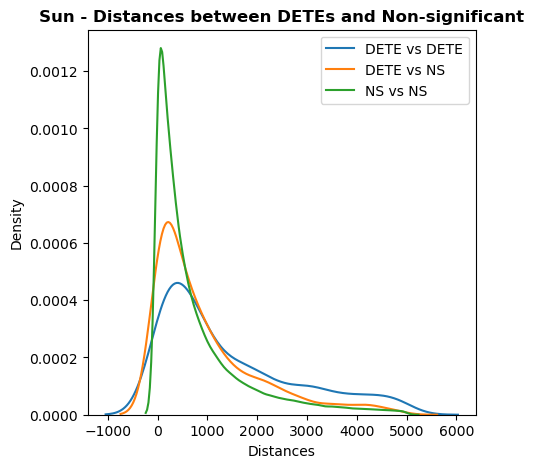

2       594
3       208
4       208
5       482
13       43
       ... 
200     296
201     296
202      16
203      16
204    1026
Name: 16, Length: 170, dtype: int64


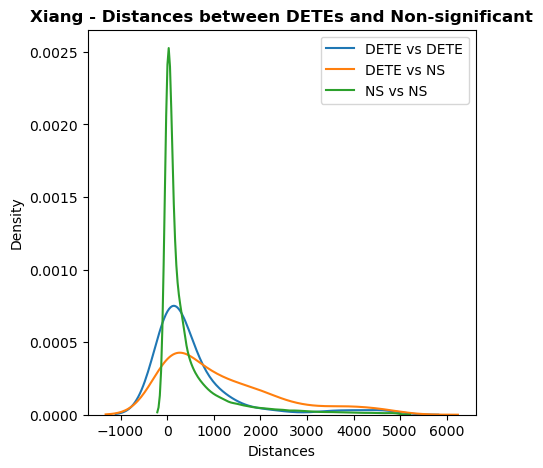

4      1774
5      1774
21      624
22      624
26      593
       ... 
666     297
667      48
668      48
669    2559
670    2559
Name: 16, Length: 249, dtype: int64


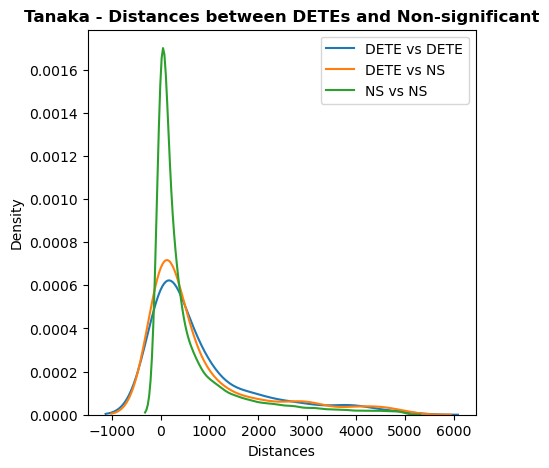

13      175
14      175
52     1232
53     1232
61      138
62      138
63      942
92      545
93      545
135     958
136     958
Name: 16, dtype: int64


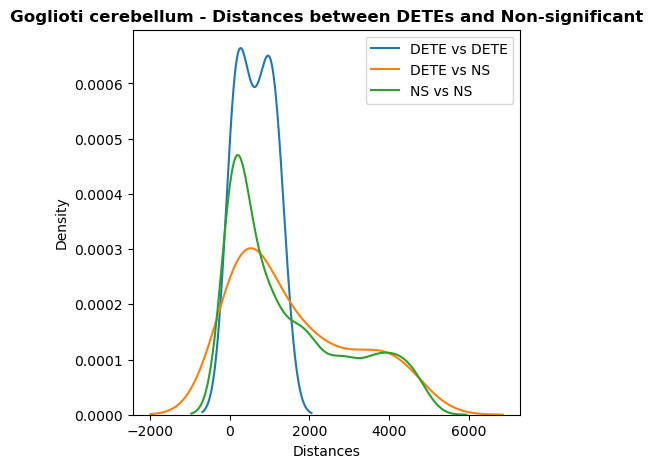

47     1167
48     1167
120     628
121     628
Name: 16, dtype: int64


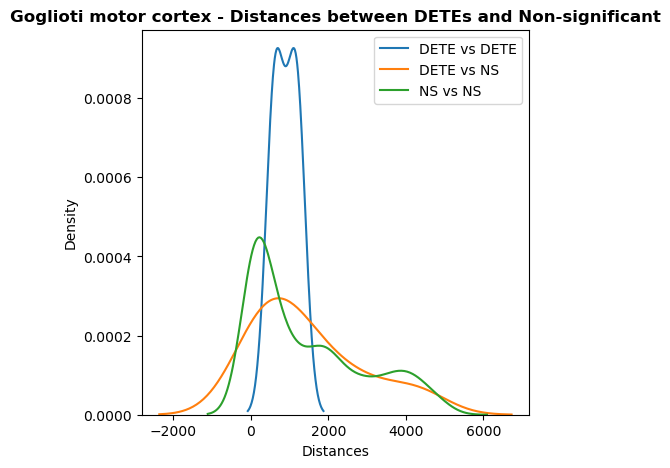

11      1078
12      1078
16       189
17       189
18       779
        ... 
1591    1052
1592     257
1593     257
1597    2584
1598    2584
Name: 16, Length: 735, dtype: int64


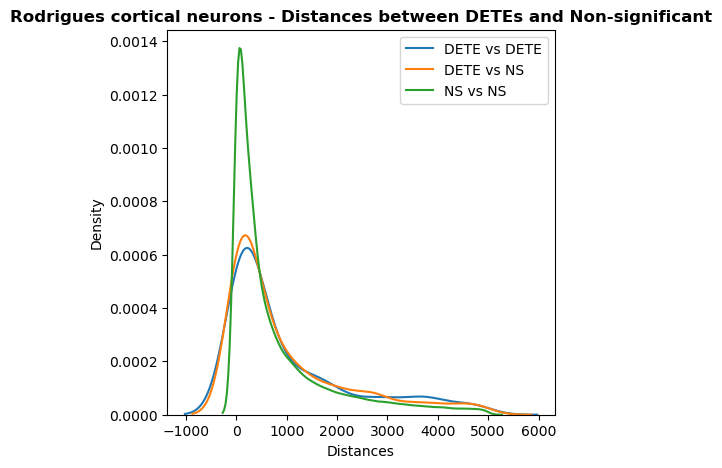

C:\Users\Ana\AppData\Local\Temp\ipykernel_34116\4272471484.py:6: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  te_te = pd.read_csv(te_te_string, sep = '\t', header = None)


14       313
15       313
19      3862
20       327
21       327
        ... 
2676    4299
2677     508
2678     508
2689    1188
2690    1188
Name: 16, Length: 2103, dtype: int64


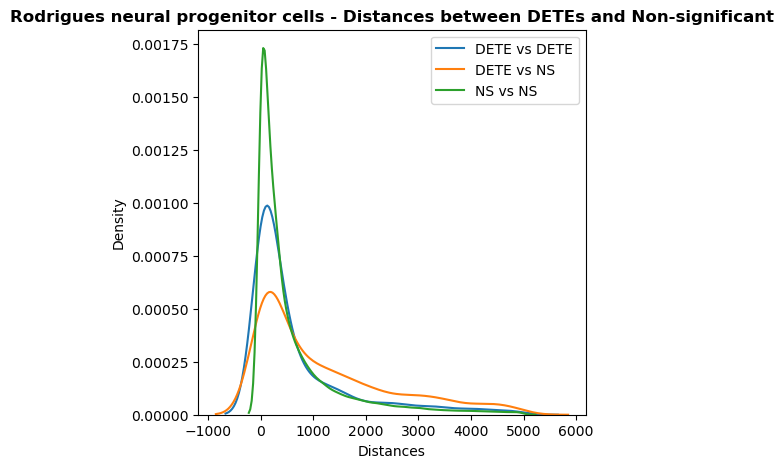

Series([], Name: 16, dtype: int64)


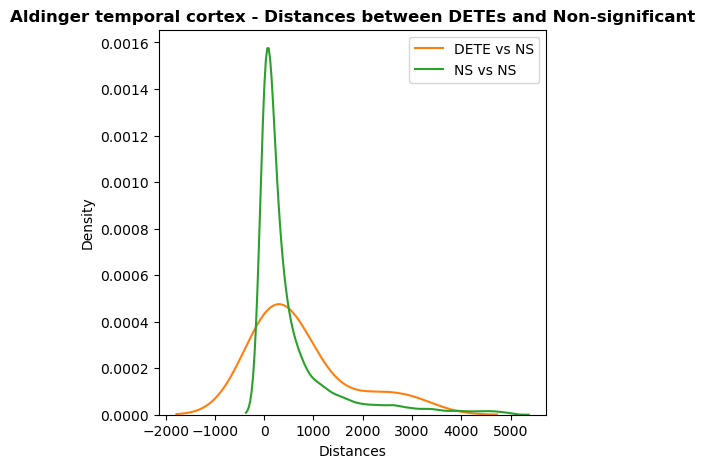

17        116
18        116
20         18
21         18
26        243
         ... 
19015     404
19040    2138
19041    2138
19043    2350
19044    2350
Name: 16, Length: 2613, dtype: int64


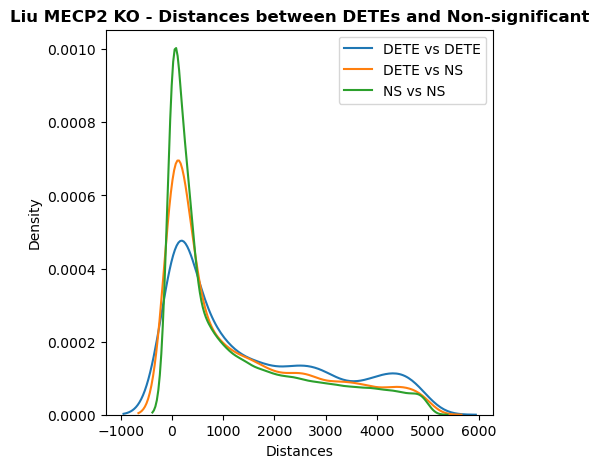

18        247
19        247
21         37
22         37
23       2908
         ... 
15525    2138
15527    2350
15528    2350
15529    1991
15530    1991
Name: 16, Length: 2729, dtype: int64


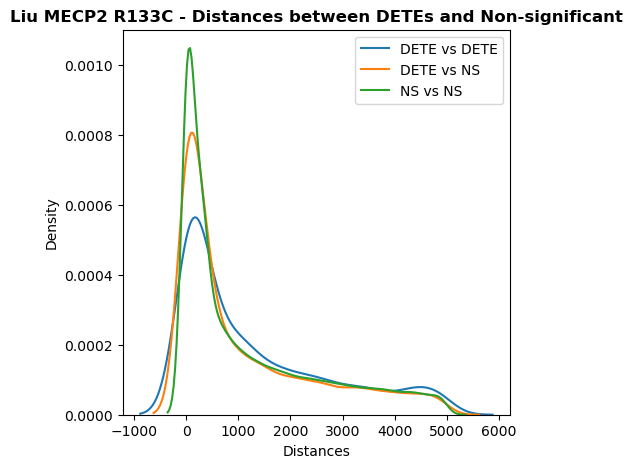

17        116
18        116
20         18
21         18
26        243
         ... 
19015     404
19040    2138
19041    2138
19043    2350
19044    2350
Name: 16, Length: 2613, dtype: int64


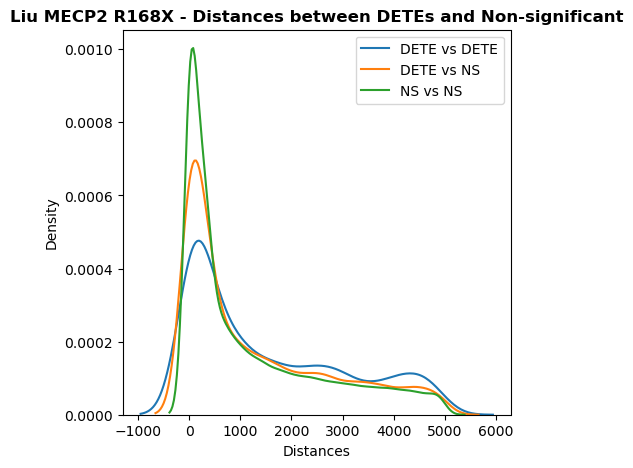

In [ ]:
#Makes a density plot in which distances between dete_dete, dete_nonsignificantly-dete and 
#nonsignificantly-dete_nonsignificantly-dete are compared
def make_density_plot(dete_dete_string, dete_te_string, te_te_string, title):

    # Read the files
    dete_dete = pd.read_csv(dete_dete_string, sep = '\t', header = None)
    dete_te = pd.read_csv(dete_te_string, sep = '\t', header = None)
    te_te = pd.read_csv(te_te_string, sep = '\t', header = None)

    # Keep only distances
    dete_dete_dist = dete_dete.iloc[:, -1]
    dete_te_dist = dete_te.iloc[:, -1]
    te_te_dist = te_te.iloc[:, -1]

    # Limit the distances
    limit = 5000
    dete_te_dist = dete_te_dist[dete_te_dist >= 0]
    dete_dete_dist = dete_dete_dist[dete_dete_dist >= 0]
    te_te_dist = te_te_dist[te_te_dist >= 0]
    dete_te_dist = dete_te_dist[dete_te_dist < limit]
    dete_dete_dist = dete_dete_dist[dete_dete_dist < limit]
    te_te_dist = te_te_dist[te_te_dist < limit]

    # Make the plot
    fig, ax = plt.subplots(figsize = (5, 5))
    print(dete_dete_dist)
    sns.kdeplot(dete_dete_dist, label = 'DETE vs DETE')
    sns.kdeplot(dete_te_dist, label = 'DETE vs NS')
    sns.kdeplot(te_te_dist, label = 'NS vs NS')

    ax.legend()
    ax.set_title(title, fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('Distances')
    plt.show()

make_density_plot(SUN_DETES_DETES, SUN_DETES_TES, SUN_TES_TES, 'Sun - Distances between DETEs and Non-significant')
make_density_plot(XIANG_DETES_DETES, XIANG_DETES_TES, XIANG_TES_TES, 'Xiang - Distances between DETEs and Non-significant')
make_density_plot(TANAKA_DETES_DETES, TANAKA_DETES_TES, TANAKA_TES_TES, 'Tanaka - Distances between DETEs and Non-significant')
make_density_plot(GOGLIOTI_CEREBELLUM_DETES_DETES, GOGLIOTI_CEREBELLUM_DETES_TES, GOGLIOTI_CEREBELLUM_TES_TES, 'Goglioti cerebellum - Distances between DETEs and Non-significant')
make_density_plot(GOGLIOTI_MOTOR_CORTEX_DETES_DETES, GOGLIOTI_MOTOR_CORTEX_DETES_TES, GOGLIOTI_MOTOR_CORTEX_TES_TES, 'Goglioti motor cortex - Distances between DETEs and Non-significant')
make_density_plot(RODRIGUES_NEU_DETES_DETES, RODRIGUES_NEU_DETES_TES, RODRIGUES_NEU_TES_TES, 'Rodrigues cortical neurons - Distances between DETEs and Non-significant')
make_density_plot(RODRIGUES_NPC_DETES_DETES, RODRIGUES_NPC_DETES_TES, RODRIGUES_NPC_TES_TES, 'Rodrigues neural progenitor cells - Distances between DETEs and Non-significant')
make_density_plot(ALDINGER_TEMPORAL_CORTEX_DETES_DETES, ALDINGER_TEMPORAL_CORTEX_DETES_TES, ALDINGER_TEMPORAL_CORTEX_TES_TES, 'Aldinger temporal cortex - Distances between DETEs and Non-significant')
make_density_plot(LIU_KO_DETES_DETES, LIU_KO_DETES_TES, LIU_KO_TES_TES, 'Liu MECP2 KO - Distances between DETEs and Non-significant')
make_density_plot(LIU_R133C_DETES_DETES, LIU_R133C_DETES_TES, LIU_R133C_TES_TES, 'Liu MECP2 R133C - Distances between DETEs and Non-significant')
make_density_plot(LIU_R168X_DETES_DETES, LIU_R168X_DETES_TES, LIU_R168X_TES_TES, 'Liu MECP2 R168X - Distances between DETEs and Non-significant')

Density plots up-regulated

        0          1          2                    3     4  5          6   \
0     chr1    9100809    9101032      TE_AluJb_dup562  1066  +        Alu   
1     chr1    9174707    9175275      TE_MLT1E1A_dup9  1907  +  ERVL-MaLR   
2     chr1    9180260    9180353        TE_L2a_dup476   297  +         L2   
3     chr1   12207627   12207924     TE_AluSx1_dup822  2383  +        Alu   
4     chr1   12208811   12208960        TE_FRAM_dup50   978  +        Alu   
...    ...        ...        ...                  ...   ... ..        ...   
1167  chrX  139121414  139121687    TE_AluJo_dup80393  1666  -        Alu   
1168  chrX  139134724  139134947  TE_AluSx1_dup121979  1598  -        Alu   
1169  chrX  139177616  139178175    TE_L1PA7_dup13005  3851  -         L1   
1170  chrX  154011091  154011389   TE_AluJb_dup130781  1980  -        Alu   
1171  chrX  154402289  154402351   TE_OldhAT1_dup4397   181  +     hAT-Ac   

        7     8          9          10                  11     12 13   14  

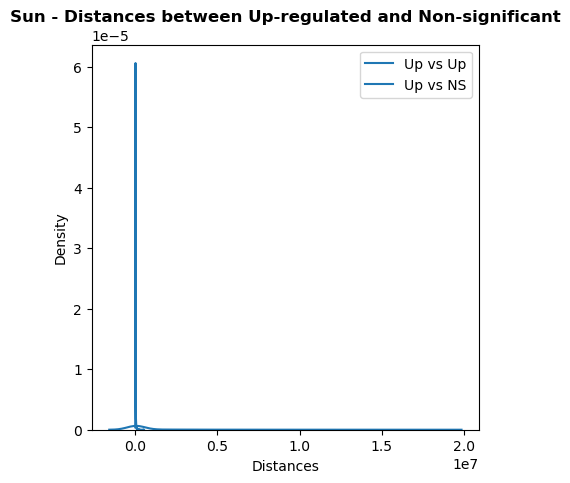

       0         1         2                   3      4  5     6     7   \
0   chr12   9354808   9355457    TE_L1PA6_dup1009   6986  -    L1  LINE   
1   chr12  34202325  34203868     TE_L1M1_dup1495   7065  +    L1  LINE   
2   chr14  19065809  19066710    TE_L1MA6_dup1390   2718  -    L1  LINE   
3   chr14  19073575  19074284     TE_L1MA1_dup831   4429  -    L1  LINE   
4   chr14  19079620  19080829    TE_L1PA4_dup2836   7362  +    L1  LINE   
..    ...       ...       ...                 ...    ... ..   ...   ...   
67   chrY  26548849  26549359   TE_L1PA11_dup4199   3280  +    L1  LINE   
68   chrY  26550384  26550776   TE_L1PA11_dup4200   2763  +    L1  LINE   
69   chrY  26582131  26585854  TE_L1PA16_dup14415  15823  -    L1  LINE   
70   chrY  26601787  26607911   TE_L1PA3_dup11085  24090  +    L1  LINE   
71   chrY  26624595  26625159    TE_LTR49_dup1549   1055  +  ERV1   LTR   

       8         9         10                    11    12 13         14    15  \
0   chr12   935422

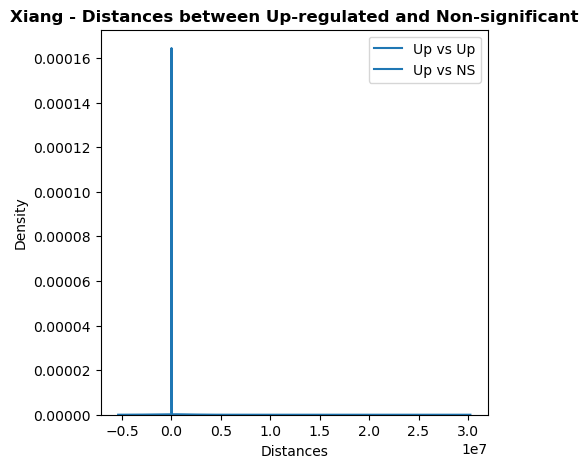

       0          1          2                   3     4  5             6   \
0    chr1   20773920   20774151      TE_MIRc_dup934   433  +           MIR   
1    chr1   23966764   23966947  TE_Tigger19b_dup20   280  -  TcMar-Tigger   
2    chr1   25244696   25244960    TE_AluJb_dup2181  1618  -           Alu   
3    chr1   25902978   25903108    TE_L1ME4a_dup295   474  +            L1   
4    chr1   50826873   50827622      TE_SVA_A_dup22  5493  +           SVA   
..    ...        ...        ...                 ...   ... ..           ...   
137  chrX   79286132   79286376   TE_AluY_dup107973  1949  -           Alu   
138  chrX  102640397  102641252    TE_L1MB5_dup9547  3087  -            L1   
139  chrX  103357989  103358207  TE_L1ME4b_dup22153   312  -            L1   
140  chrX  103685462  103685634   TE_L1MC5_dup15635   584  -            L1   
141  chrX  120437873  120438156  TE_AluSq2_dup62759  2338  -           Alu   

             7     8          9          10                    

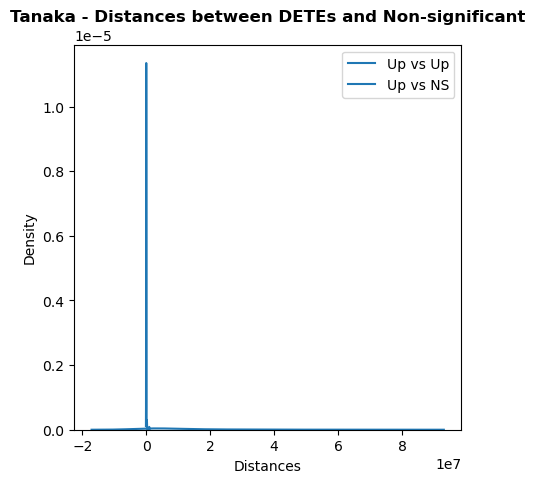

       0          1          2                   3     4  5            6   \
0    chr1   12572623   12572742     TE_MER117_dup18   248  -  hAT-Charlie   
1    chr1   23441037   23441124      TE_MIR_dup2086   265  +          MIR   
2    chr1   65601809   65601923  TE_MIR1_Amn_dup574   188  -          MIR   
3    chr1  161517820  161518039  TE_MER57-int_dup49   475  +         ERV1   
4    chr1  161518213  161518545     TE_MER57F_dup18   772  +         ERV1   
..    ...        ...        ...                 ...   ... ..          ...   
113  chrX   77901729   77902035   TE_AluJr_dup86561  1936  -          Alu   
114  chrX   81114672   81115052    TE_HAL1_dup22983   381  -           L1   
115  chrX  103790856  103790903  TE_MamTip2_dup6561   184  -   hAT-Tip100   
116  chrX  108582630  108582864   TE_L1ME1_dup31155  1073  -           L1   
117  chrX  108591712  108592082    TE_L2a_dup170891  1216  +           L2   

       7     8          9          10                    11    12 13  \
0  

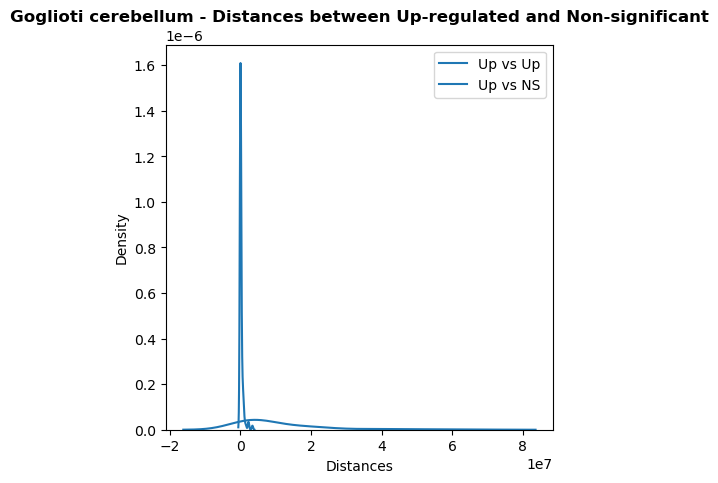

      0          1          2                   3     4  5             6   \
0   chr1     732047     732235      TE_AluJb_dup31  1109  +           Alu   
1   chr1   23441037   23441124      TE_MIR_dup2086   265  +           MIR   
2   chr1   26942520   26942620      TE_L2b_dup1513   212  +            L2   
3   chr1   28246532   28246727     TE_L1MC4a_dup87   290  -            L1   
4   chr1   46636055   46636306      TE_L2c_dup3078   466  +            L2   
..   ...        ...        ...                 ...   ... ..           ...   
57  chr8  103307764  103307844   TE_MLT1N2_dup5103   348  -     ERVL-MaLR   
58  chr9   77369686   77370207  TE_Tigger6b_dup295  2383  -  TcMar-Tigger   
59  chrX   73823485   73823548    TE_L2a_dup169661   185  +            L2   
60  chrX   73824175   73824226     TE_L2b_dup96098   239  +            L2   
61  chrX   73847404   73847519  TE_FLAM_C_dup24649   749  -           Alu   

      7     8          9          10                  11    12 13  \
0   SI

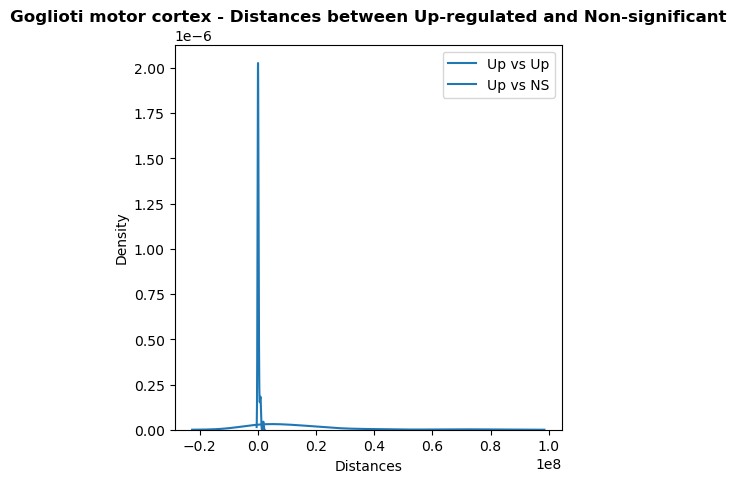

       0          1          2                   3     4  5            6   \
0    chr1    8576388    8576448    TE_Kanga11a_dup1   246  +    TcMar-Tc2   
1    chr1    9928347    9928596      TE_L1MB5_dup67  3079  +           L1   
2    chr1   19216476   19216545      TE_L1MA2_dup21   413  +           L1   
3    chr1   64943235   64943345     TE_MIRc_dup4116   205  -          MIR   
4    chr1   66016343   66016397      TE_L2a_dup5640   197  -           L2   
..    ...        ...        ...                 ...   ... ..          ...   
945  chrX  149479498  149479652    TE_L1M5_dup56036   512  +           L1   
946  chrX  149482235  149482297    TE_MER33_dup9782   262  +  hAT-Charlie   
947  chrX  151406087  151406209  TE_L1ME4a_dup34674   395  -           L1   
948  chrX  154089365  154089489  TE_L1ME3G_dup16773   303  +           L1   
949  chrX  155105991  155106588    TE_L1M5_dup56208   523  -           L1   

       7     8          9          10                   11    12 13  \
0   

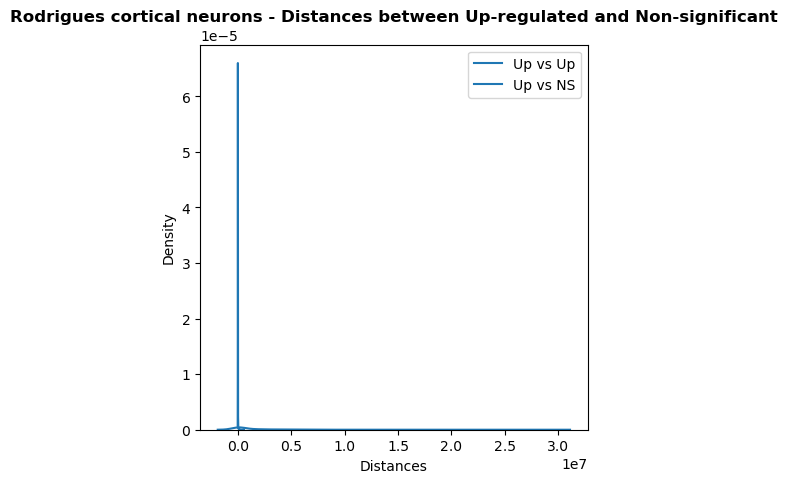

        0          1          2                   3      4  5          6   \
0     chr1   61106758   61108657    TE_L1ME3F_dup132   1982  -         L1   
1     chr1   65230495   65230552    TE_MIRb_dup10516    181  -        MIR   
2     chr1   66027459   66029037  TE_THE1A-int_dup35  11904  -  ERVL-MaLR   
3     chr1   66057855   66059423  TE_THE1B-int_dup43  11356  -  ERVL-MaLR   
4     chr1   66092428   66092826      TE_L2b_dup4518    466  -         L2   
...    ...        ...        ...                 ...    ... ..        ...   
1365  chrX  148123449  148129475   TE_L1PA3_dup10831  27748  -         L1   
1366  chrX  149553805  149554449    TE_MER51C_dup184   4490  +       ERV1   
1367  chrX  154060459  154062454    TE_L2a_dup173545    452  -         L2   
1368  chrX  154088116  154088178     TE_L2b_dup98174    233  +         L2   
1369  chrX  154089365  154089489  TE_L1ME3G_dup16773    303  +         L1   

        7     8          9          10                     11     12 13  \


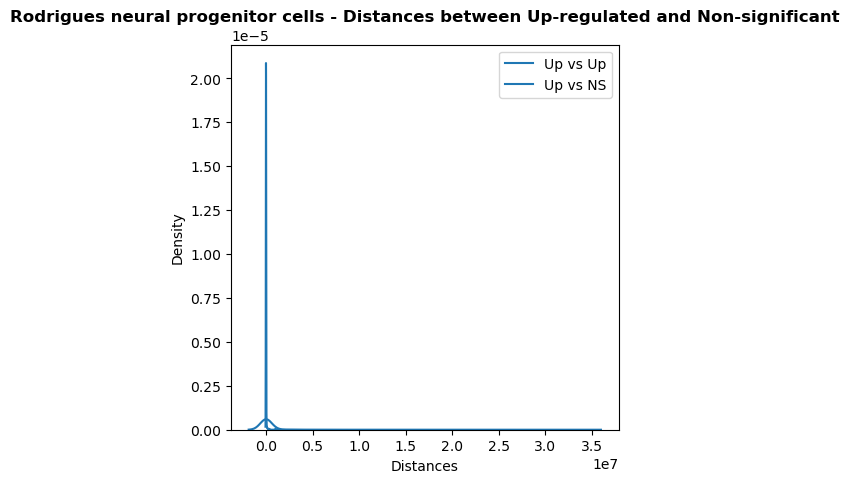

      0         1         2                   3     4  5           6     7   \
0  chr10  71714606  71714799       TE_L2_dup6643   260  -          L2  LINE   
1  chr14  81266850  81266941      TE_L3_dup13743   200  -         CR1  LINE   
2  chr14  94625001  94625262     TE_L2c_dup44697   364  -          L2  LINE   
3  chr15  63324687  63324796   TE_AluSx3_dup9571   903  -         Alu  SINE   
4  chr17    440802    441061   TE_AluSg_dup13262  2061  +         Alu  SINE   
5  chr18  45751507  45751786   TE_AluJo_dup34811  1732  +         Alu  SINE   
6  chr21  42372277  42372579  TE_AluSx1_dup72547  2239  +         Alu  SINE   
7  chr22  37225488  37225736      TE_L3_dup25284   440  +         CR1  LINE   
8   chr4  78680661  78681060    TE_MLT1J_dup9980   549  -   ERVL-MaLR   LTR   
9   chr5  95793796  95793956   TE_MER45A_dup2604   809  +  hAT-Tip100   DNA   

      8         9         10                     11    12 13           14  \
0  chr10  71712371  71712508        TE_MIR_dup19812  

C:\Users\Ana\AppData\Local\Temp\ipykernel_34116\170061261.py:48: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(dete_dete_dist, label = 'Up vs Up')


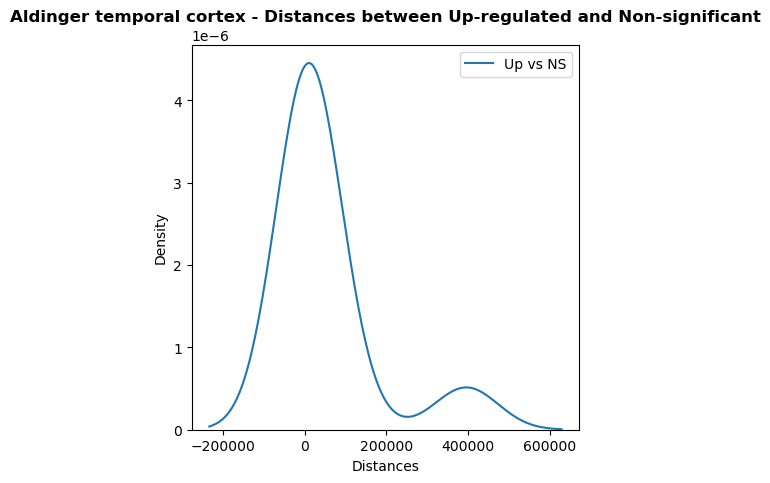

         0          1          2                       3      4  5   \
0      chr1      78890      79850         TE_L1PREC2_dup1   5656  +   
1      chr1    1417490    1418377   TE_Harlequin-int_dup4   5980  -   
2      chr1    1812191    1812352           TE_L1PA6_dup5   1174  +   
3      chr1    2156875    2157339          TE_MLT2B1_dup1   1758  -   
4      chr1    2577230    2577523         TE_AluSq2_dup79   2213  +   
...     ...        ...        ...                     ...    ... ..   
16697  chrX  155683673  155684399         TE_L2b_dup98213   1006  -   
16698  chrY    9141680    9141905  TE_HUERS-P3-int_dup728    780  -   
16699  chrY   13691338   13697314       TE_L1PA3_dup10955  24834  +   
16700  chrY   56837123   56851635     TE_BSR/Beta_dup2041   1158  -   
16701  chrY   56859952   56860360       TE_L1MEd_dup22133    424  +   

              6          7     8          9          10  \
0             L1       LINE  chr1      81693      82270   
1           ERV1        LTR  

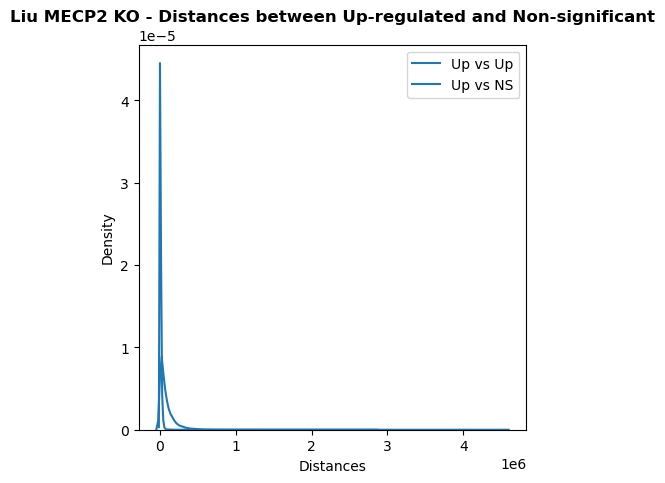

         0          1          2                      3      4  5          6   \
0      chr1    1114804    1115033          TE_L1PB1_dup1   1188  +         L1   
1      chr1    1417490    1418377  TE_Harlequin-int_dup4   5980  -       ERV1   
2      chr1    2792268    2793044          TE_L1MEb_dup2    990  -         L1   
3      chr1    4029569    4030480         TE_L1ME1_dup30   4894  -         L1   
4      chr1    4180996    4185574      TE_HERVH-int_dup1  34034  -       ERV1   
...     ...        ...        ...                    ...    ... ..        ...   
12341  chrX  155444867  155448478      TE_L1MA4A_dup6246  13870  +         L1   
12342  chrX  155605236  155609559      TE_L1PA15_dup8434  16103  +         L1   
12343  chrX  155683673  155684399        TE_L2b_dup98213   1006  -         L2   
12344  chrY   56837123   56851635    TE_BSR/Beta_dup2041   1158  -  Satellite   
12345  chrY   56859952   56860360      TE_L1MEd_dup22133    424  +         L1   

              7     8      

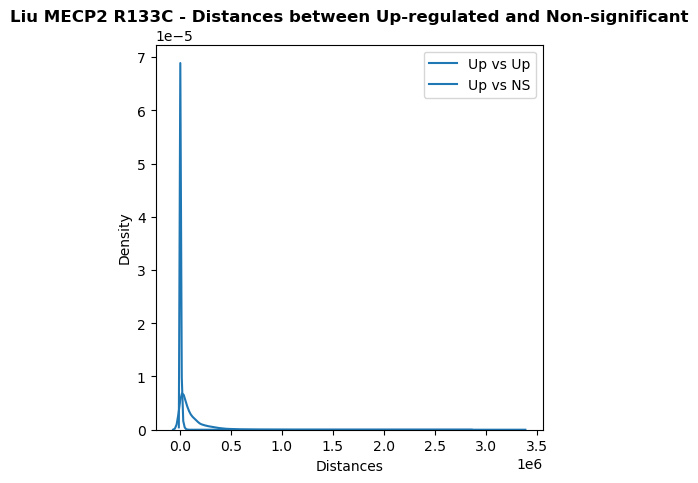

         0          1          2                       3      4  5   \
0      chr1      78890      79850         TE_L1PREC2_dup1   5656  +   
1      chr1    1417490    1418377   TE_Harlequin-int_dup4   5980  -   
2      chr1    1812191    1812352           TE_L1PA6_dup5   1174  +   
3      chr1    2156875    2157339          TE_MLT2B1_dup1   1758  -   
4      chr1    2577230    2577523         TE_AluSq2_dup79   2213  +   
...     ...        ...        ...                     ...    ... ..   
16697  chrX  155683673  155684399         TE_L2b_dup98213   1006  -   
16698  chrY    9141680    9141905  TE_HUERS-P3-int_dup728    780  -   
16699  chrY   13691338   13697314       TE_L1PA3_dup10955  24834  +   
16700  chrY   56837123   56851635     TE_BSR/Beta_dup2041   1158  -   
16701  chrY   56859952   56860360       TE_L1MEd_dup22133    424  +   

              6          7     8          9          10  \
0             L1       LINE  chr1      81693      82270   
1           ERV1        LTR  

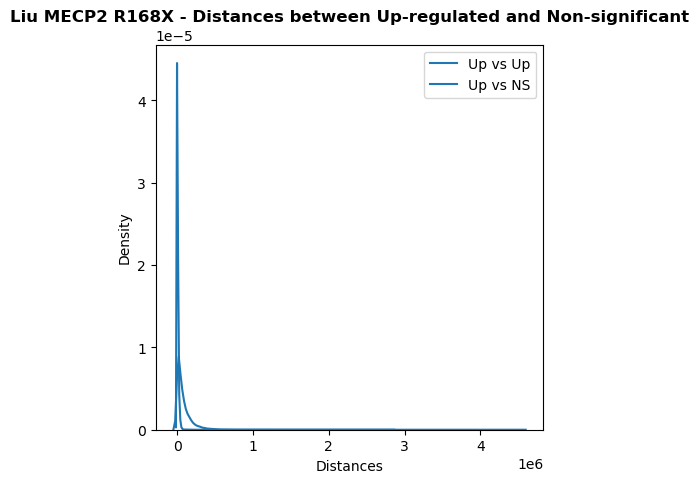

In [8]:
def make_density_plot_up(dete_dete_string, dete_te_string, title):

    # Read the files
    dete_dete = pd.read_csv(dete_dete_string, sep = '\t', header = None)
    dete_te = pd.read_csv(dete_te_string, sep = '\t', header = None)
    print(dete_te)

    # Keep only distances
    dete_dete_dist = dete_dete.iloc[:, [3, 11, 16]]
    dete_te_dist = dete_te.iloc[:, [3, 11, 16]]
    print('before')
    print(dete_dete_dist.iloc[:, [0, 1]])
    print(dete_te_dist.iloc[:, [0, 1]])


    # Limit the distances
    limit = 1000000000
    tmp_dete_te = dete_te_dist[dete_te_dist.iloc[:, 2] == 0]
    tmp_dete_dete = dete_dete_dist[dete_dete_dist.iloc[:, 2] == 0]

    # Debug
    print('DETE_TE')
    print(tmp_dete_te.iloc[:, [0, 1]])
    tmp_dete_te.columns = ['DETE_ID', 'TE_ID', 'Distance']
    print(gtf_df)
    print('DETE_ID')
    dete_ids = gtf_df[['Chr', 'Start', 'End', 'Strand', 'Gene_name']]
    dete_ids = dete_ids.merge(tmp_dete_te, left_on = 'Gene_name', right_on = 'DETE_ID', how = 'inner' )
    print(dete_ids[['Chr', 'Start', 'End', 'Strand', 'Gene_name', 'DETE_ID', 'TE_ID']])

    print('TE_ID')
    te_ids = gtf_df[['Chr', 'Start', 'End', 'Strand', 'Gene_name']]
    te_ids = gtf_df.merge(tmp_dete_te, left_on = 'Gene_name', right_on = 'TE_ID', how = 'inner')
    print(te_ids[['Chr', 'Start', 'End', 'Strand', 'Gene_name', 'TE_ID', 'DETE_ID']])

    print('distances')
    print(tmp_dete_te.iloc[:, 2])
    # ate aqui

    dete_te_dist = dete_te_dist[dete_te_dist.iloc[:, 2] >= 0]
    dete_dete_dist = dete_dete_dist[dete_dete_dist.iloc[:, 2] >= 0]
    dete_te_dist = dete_te_dist[dete_te_dist.iloc[:, 2] < limit]
    dete_dete_dist = dete_dete_dist[dete_dete_dist.iloc[:, 2] < limit]

    # Make the plot
    fig, ax = plt.subplots(figsize = (5, 5))
    print(dete_dete_dist)
    sns.kdeplot(dete_dete_dist, label = 'Up vs Up')
    sns.kdeplot(dete_te_dist, label = 'Up vs NS')

    ax.legend()
    ax.set_title(title, fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('Distances')
    plt.show()

make_density_plot_up(SUN_UP_UP, SUN_UP_NS, 'Sun - Distances between Up-regulated and Non-significant')
make_density_plot_up(XIANG_UP_UP, XIANG_UP_NS, 'Xiang - Distances between Up-regulated and Non-significant')
make_density_plot_up(TANAKA_UP_UP, TANAKA_UP_NS, 'Tanaka - Distances between DETEs and Non-significant')
make_density_plot_up(GOGLIOTI_CEREBELLUM_UP_UP, GOGLIOTI_CEREBELLUM_UP_NS, 'Goglioti cerebellum - Distances between Up-regulated and Non-significant')
make_density_plot_up(GOGLIOTI_MOTOR_CORTEX_UP_UP, GOGLIOTI_MOTOR_CORTEX_UP_NS, 'Goglioti motor cortex - Distances between Up-regulated and Non-significant')
make_density_plot_up(RODRIGUES_NEU_UP_UP, RODRIGUES_NEU_UP_NS, 'Rodrigues cortical neurons - Distances between Up-regulated and Non-significant')
make_density_plot_up(RODRIGUES_NPC_UP_UP, RODRIGUES_NPC_UP_NS, 'Rodrigues neural progenitor cells - Distances between Up-regulated and Non-significant')
make_density_plot_up(ALDINGER_TEMPORAL_CORTEX_UP_UP, ALDINGER_TEMPORAL_CORTEX_UP_NS, 'Aldinger temporal cortex - Distances between Up-regulated and Non-significant')
make_density_plot_up(LIU_KO_UP_UP, LIU_KO_UP_NS, 'Liu MECP2 KO - Distances between Up-regulated and Non-significant')
make_density_plot_up(LIU_R133C_UP_UP, LIU_R133C_UP_NS, 'Liu MECP2 R133C - Distances between Up-regulated and Non-significant')
make_density_plot_up(LIU_R168X_UP_UP, LIU_R168X_UP_NS, 'Liu MECP2 R168X - Distances between Up-regulated and Non-significant')


ManWhitney U test

In [9]:
# Read the files
up_up = pd.read_csv(RODRIGUES_NPC_UP_UP, sep = '\t', header = None)
up_ns = pd.read_csv(RODRIGUES_NPC_UP_NS, sep = '\t', header = None)

# Keep only distances
up_up_dist = up_up.iloc[:, -1]
up_ns_dist = up_ns.iloc[:, -1]

# Remove -1!!!!
up_up_dist = up_up_dist[up_up_dist >= 0]
up_ns_dist = up_ns_dist[up_ns_dist >= 0]

# Downsampling preparation
num_perm = 1000
up_ns_dist_array = np.array(up_ns_dist)
up_size = len(up_up_dist)

u_stats = []
p_values = []
median_diffs = []

# Permutaiton test / Downsampling
for _ in range(num_perm):
    perm_ns = np.random.choice(up_ns_dist_array, size = up_size, replace = False)
    stat, p_value = stats.mannwhitneyu(x = up_up_dist, y = perm_ns, alternative = 'two-sided')

    median_diff = np.median(perm_ns) - np.median(up_up_dist)
    median_diffs.append(median_diff)
    u_stats.append(stat)
    p_values.append(p_value)
    
print(np.mean(np.array(median_diffs) > 0))
print(np.array(p_values))
print(np.mean(np.array(p_values) < 0.05 ))

1.0
[0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346
 0.61706346 0.61706346 0.61706346 0.61706346 0.61706346 0.

Violin plot

           0          1          2                      3      4  5  \
0       chr1      78890      79850        TE_L1PREC2_dup1   5656  +   
1       chr1    1417490    1418377  TE_Harlequin-int_dup4   5980  -   
2       chr1    1563251    1563558         TE_AluSg7_dup8   2223  +   
3       chr1    1655403    1655487            TE_L2_dup28    213  +   
4       chr1    1736215    1736518         TE_AluY_dup119   2436  +   
...      ...        ...        ...                    ...    ... ..   
121771  chrX  120437873  120438156     TE_AluSq2_dup62759   2338  -   
121772  chrX  123913087  123913167       TE_MER2B_dup1932    330  +   
121773  chrX  135311861  135318027      TE_L1MA4A_dup6157  16938  -   
121774  chrX  153802382  153802469         TE_L3_dup45830    252  -   
121775  chrY   12562270   12564968   TE_HERVH-int_dup5928  13366  -   

                   6     7     8          9         10               11 12 13  \
0                 L1  LINE  chr1     916863     921016        LINC

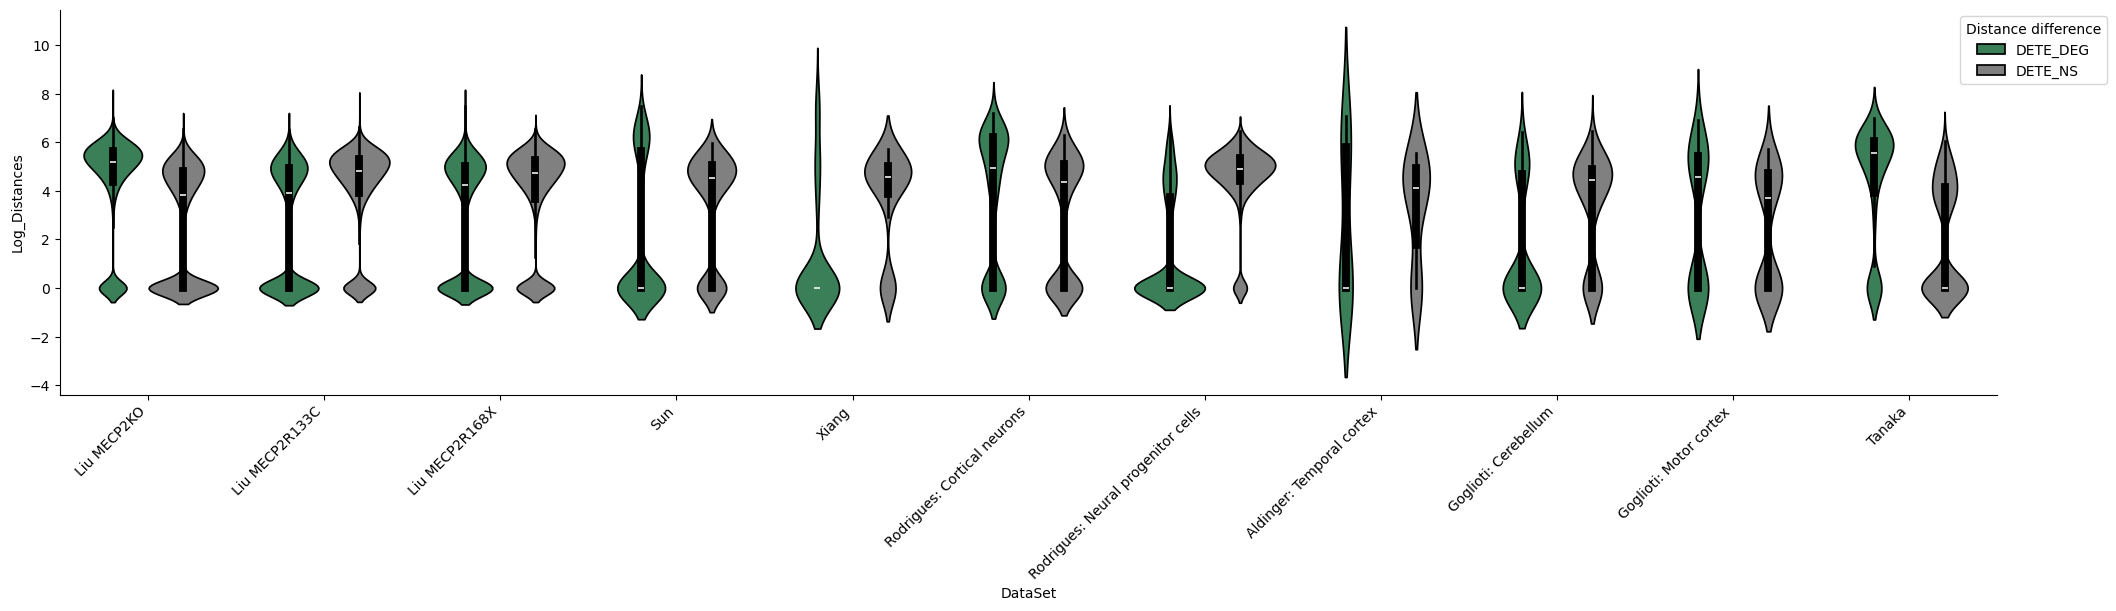

In [ ]:
# Merges beds
def merge_beds(dict, condition):
    dfs = []

    for dataset_name, filepath in dict.items():
        df = pd.read_csv(filepath, sep = '\t', header = None)
        df['DataSet'] = dataset_name
        df['Condition'] = condition
        dfs.append(df)
    
    merged = pd.concat(dfs, ignore_index = True)
    return merged

# Gets the datasets in which the difference in distances was statistically significant
def get_significant_datasets(merged_df):

    significant_datasets = []

    for dataset in merged_df['DataSet'].unique():
        subset = merged_df[merged_df['DataSet'] == dataset]
        group_up_up = subset[subset['Condition'] == 'Up_Up']['Log_Distances']
        group_up_ns = subset[subset['Condition'] == 'Up_Ns']['Log_Distances']

        if (len(group_up_up) > 0) and (len(group_up_ns) > 0):
            stat, p = stats.mannwhitneyu(x = group_up_up, y = group_up_ns, alternative = 'two-sided')

            if (p < 0.05):
                significant_datasets.append(dataset)
    
    return significant_datasets

# Prints an * on the violin plot in the datasets in which the distance difference was statistically significant
def print_significant_datasets(merged_df, ax):
    significant_datasets = get_significant_datasets(merged_df)

    for position_in_x, dataset in enumerate(merged_df['DataSet'].unique()):
        if (dataset in significant_datasets):
            subset = merged_df[merged_df['DataSet'] == dataset]
            y = subset['Log_Distances'].max()

            ax.text(position_in_x, y + 0.1, "*", ha='center', va='bottom', fontsize=18)


# Makes a volcano plot  in which up_up_dict is compared with up_ns_dict
def organize_for_violin_plot(up_up_dict, up_ns_dict):
    up_up_df = merge_beds(up_up_dict, 'DETE_DEG')
    up_ns_df = merge_beds(up_ns_dict, 'DETE_NS')
    
    merged_df = pd.concat([up_up_df, up_ns_df], ignore_index = True)

    print(merged_df)
    print(merged_df.index.is_unique)
    merged_df = merged_df.rename(columns = {merged_df.columns[-3] : 'Distances'})
    merged_df = merged_df[merged_df['Distances'] >= 0]
    merged_df['Log_Distances'] = np.log10(merged_df['Distances'] + 1)
    
    fig, ax = plt.subplots(figsize = (25, 5))
    print(merged_df)
    sns.violinplot(data = merged_df,
                   x = 'DataSet',
                   y = 'Log_Distances',
                   hue = 'Condition',
                   palette = {'DETE_DEG' : 'seagreen',
                              'DETE_NS' : 'grey'},
                   edgecolor = 'black')
    
    plt.xticks(rotation = 45, ha="right")
    print_significant_datasets(merged_df, ax)
    ax.legend(title = 'Distance difference', loc='upper right', bbox_to_anchor=(1.06, 1))  
    plt.title('', fontweight = 'bold', fontsize = 12)
    
    sns.despine()
    plt.show()

# Up_up intergenic information
up_up_dict = {'Liu MECP2KO' : LIU_KO_UP_UP_INTERGENIC,
              'Liu MECP2R133C' : LIU_R133C_UP_UP_INTERGENIC,
              'Liu MECP2R168X' : LIU_R168X_UP_UP_INTERGENIC,
              'Rodrigues: Cortical neurons' : RODRIGUES_NEU_UP_UP_INTERGENIC,
              'Rodrigues: Neural progenitor cells' : RODRIGUES_NPC_UP_UP_INTERGENIC}

# Up_ns intergenic information
up_ns_dict = {'Liu MECP2KO' : LIU_KO_UP_NS_INTERGENIC,
              'Liu MECP2R133C' : LIU_R133C_UP_NS_INTERGENIC,
              'Liu MECP2R168X' : LIU_R168X_UP_NS_INTERGENIC,       
              'Rodrigues: Cortical neurons' : RODRIGUES_NEU_UP_NS_INTERGENIC,
              'Rodrigues: Neural progenitor cells' : RODRIGUES_NPC_UP_NS_INTERGENIC}

# Down_down intergenic information
down_down_dict = {'Liu MECP2KO' : LIU_KO_DOWN_DOWN_INTERGENIC,
                  'Liu MECP2R133C' : LIU_R133C_DOWN_DOWN_INTERGENIC,
                  'Liu MECP2R168X' : LIU_R168X_DOWN_DOWN_INTERGENIC,       
                  'Rodrigues: Cortical neurons' : RODRIGUES_NEU_DOWN_DOWN_INTERGENIC,
                  'Rodrigues: Neural progenitor cells' : RODRIGUES_NPC_DOWN_DOWN_INTERGENIC}

# DETE_DEG information
dete_deg_dict = {'Liu MECP2KO' : LIU_KO_DETEs_DEGs,
                 'Liu MECP2R133C' : LIU_R133C_DETEs_DEGs,
                 'Liu MECP2R168X' : LIU_R168X_DETEs_DEGs,  
                 'Sun' : SUN_DETEs_DEGs,
                 'Xiang' : XIANG_DETEs_DEGs,     
                 'Rodrigues: Cortical neurons' : RODRIGUES_NEU_DETEs_DEGs,
                 'Rodrigues: Neural progenitor cells' : RODRIGUES_NPC_DETEs_DEGs,
                 'Aldinger: Temporal cortex' : ALDINGER_TEMPORAL_CORTEX_DETEs_DEGs,
                 'Goglioti: Cerebellum' : GOGLIOTI_CEREBELLUM_DETEs_DEGs,
                 'Goglioti: Motor cortex' : GOGLIOTI_MOTOR_CORTEX_DETEs_DEGs,
                 'Tanaka' : TANAKA_DETEs_DEGs}

#DETE_ns_genes information
dete_ns_genes_dict = {'Liu MECP2KO' : LIU_KO_DETEs_NS_GENES,
                     'Liu MECP2R133C' : LIU_R133C_DETEs_NS_GENES,
                     'Liu MECP2R168X' : LIU_R168X_DETEs_NS_GENES,  
                     'Sun' : SUN_DETEs_NS_GENES,
                     'Xiang' : XIANG_DETEs_NS_GENES,     
                     'Rodrigues: Cortical neurons' : RODRIGUES_NEU_DETEs_NS_GENES,
                     'Rodrigues: Neural progenitor cells' : RODRIGUES_NPC_DETEs_NS_GENES,
                     'Aldinger: Temporal cortex' : ALDINGER_TEMPORAL_CORTEX_DETEs_NS_GENES,
                     'Goglioti: Cerebellum' : GOGLIOTI_CEREBELLUM_DETEs_NS_GENES,
                     'Goglioti: Motor cortex' : GOGLIOTI_MOTOR_CORTEX_DETEs_NS_GENES,
                     'Tanaka' : TANAKA_DETEs_NS_GENES}

organize_for_violin_plot(dete_deg_dict, dete_ns_genes_dict)
